In [1]:
import os 
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 16,          # base size (ticks, default text)
    "axes.titlesize": 16,      # axes title
    "axes.labelsize": 16,      # x/y label
    "xtick.labelsize": 16,     # x tick labels
    "ytick.labelsize": 16,     # y tick labels
    "legend.fontsize": 16,     # legend
    "figure.titlesize": 16,    # suptitle
})

In [3]:
from cycler import cycler
import seaborn as sns
pal = sns.color_palette("hls", desat=0.7)
plt.rcParams["axes.prop_cycle"] = cycler(color=pal)

In [4]:
# -----------------------------
# Helper: mean/std of curves
# -----------------------------
def mean_std(curves, eps=1e-12):
    """
    curves: list of 1D arrays, each length = steps
    returns: mean, std (both 1D)
    """
    arr = np.stack([np.asarray(c) for c in curves], axis=0)  # (S, T)
    m = arr.mean(axis=0)
    s = arr.std(axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(m)
    # For semilogy shading: ensure strictly positive
    m = np.maximum(m, eps)
    return m, s

In [5]:
def log_mean_band(y, eps=1e-30):
    y = np.asarray(y)
    y = np.where(np.isfinite(y) & (y > 0), y, np.nan)
    ly = np.log(np.maximum(y, eps))

    m = np.exp(np.nanmean(ly, axis=0))
    s = np.nanstd(ly, axis=0)

    lower = m * np.exp(-s)
    upper = m * np.exp(+s)
    return m, lower, upper

def log_median_iqr_band(y, qlo=0.25, qhi=0.75, eps=1e-30):
    """
    Log-space median with [qlo, qhi] quantile band.
    Works well when you plot on a log y-axis (multiplicative uncertainty).
    """
    y = np.asarray(y)
    # keep only finite, positive values; others -> NaN
    y = np.where(np.isfinite(y) & (y > 0), y, np.nan)

    ly = np.log(np.maximum(y, eps))

    med = np.exp(np.nanmedian(ly, axis=0))
    lo  = np.exp(np.nanquantile(ly, qlo, axis=0))
    hi  = np.exp(np.nanquantile(ly, qhi, axis=0))

    return med, lo, hi

In [6]:
label_map = {
    "signsgd":   lambda t: f"SignSGD",
    "adam":      lambda t: f"Adam",
    "muon":      lambda t: f"Muon",
    "soap":      lambda t: f"SOAP",
    "deva_linfty":  lambda t: r"DeVA $\ell_\infty$",
    "deva_sinfty":   lambda t: r"DeVA $S_\infty$",
    "adamuon":   lambda t: f"Adamuon",
    "gd":        lambda t: r"GD",
}

In [7]:
def plot_logmag(H, title=None, ax=None, eps=1e-12, add_colorbar=False, cbar_kw=None):
    """
    Plot log10(|H|+eps) as an image with proper colorbar alignment for insets.
    """
    if cbar_kw is None:
        cbar_kw = {}

    Hnp = H.detach().cpu().numpy() if hasattr(H, "detach") else np.asarray(H)
    img = np.log10(np.abs(Hnp) + eps)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    im = ax.imshow(img, cmap="coolwarm")
    ax.set_adjustable("box") # This is the "magic" line

    if title is not None:
        ax.set_title(title)

    ax.set_xticks([])
    ax.set_yticks([])

    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

    if add_colorbar and ax.figure is not None:
        # Create a dedicated colorbar axes (cax) relative to the current 'ax'
        # This pins the colorbar to the right of the inset
        cax = inset_axes(
            ax,
            width="5%",             # Width of the colorbar
            height="100%",          # Match height of the image
            loc='lower left',
            bbox_to_anchor=(1.05, 0., 1, 1), # Offset slightly to the right (1.05)
            bbox_transform=ax.transAxes,
            borderpad=0
        )
        # Explicitly use cax so Matplotlib doesn't 'steal' space from ax
        cb = ax.figure.colorbar(im, cax=cax, **cbar_kw)
        cb.ax.tick_params(labelsize=7) # Small labels for insets

    return ax, im

dict_keys(['subopt', 'time', 'L_norm', 'H_norm', 'H', 'gamma'])
dict_keys(['gd', 'signsgd', 'adam', 'muon', 'soap', 'deva_sinfty', 'deva_sinfty_sign', 'deva_linfty', 'adamuon'])
dict_keys(['subopt', 'time', 'L_norm', 'H_norm', 'H', 'gamma'])
dict_keys(['gd', 'signsgd', 'adam', 'muon', 'soap', 'deva_sinfty', 'deva_sinfty_sign', 'deva_linfty', 'adamuon'])


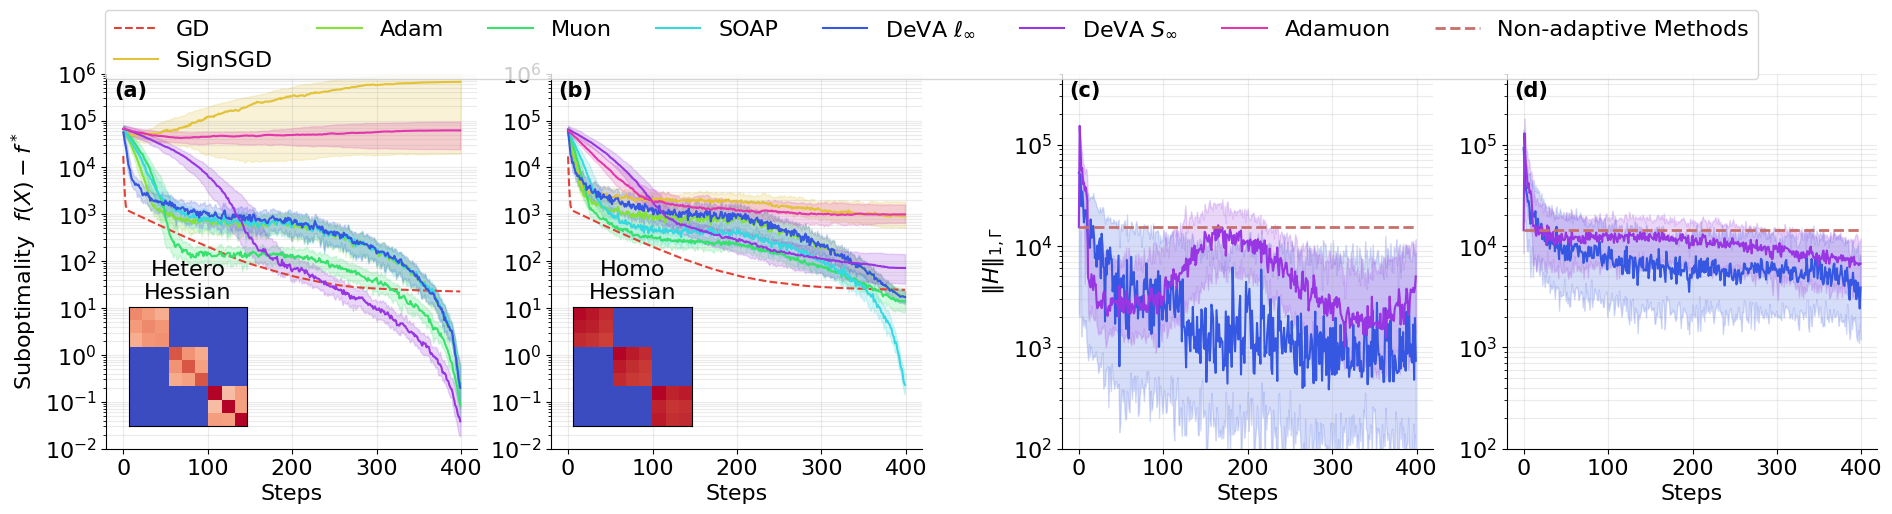

In [9]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors

## set the number of seeds you used in trace_quadratic.py
num_seeds = 100
steps = 400
beta_1 = 0.0
beta_2 = 0.99
fig, axes = plt.subplots(1, 4, figsize=(22,5))

## visualize adamuon if you have the results from trace_quadratic.py
# names = ['gd', "signsgd", "adam", "muon", "soap", "deva_linfty", "deva_sinfty"]
names = ['gd', "signsgd", "adam", "muon", 
"soap", "deva_linfty", "deva_sinfty", "adamuon"]
dualnorm_plot_list = ['deva_linfty', "deva_sinfty"]

palette = sns.hls_palette(n_colors=len(names), l=0.55, s=0.75)  # tweak l/s if you want
name2color = {m: palette[i] for i, m in enumerate(names)}       # RGB in [0,1]
name2hex   = {m: mcolors.to_hex(name2color[m]) for m in names}  # hex

for i, heter in enumerate([True, False]):
    ax = axes[i]
    with open(f'../results/trace_quadratic_{num_seeds}seeds_{heter}_beta1_{beta_1}_beta2_{beta_2}.json', "r") as f:
        res = json.load(f)

    ## we first plot suboptimality
    print(res.keys())
    all_subopt = res['subopt']
    print(all_subopt.keys())
    all_time = res['time']


    Hessian_plot_title = "Hetero\nHessian" if heter else "Homo\nHessian"
    H_inset = res['H']
    # inset in lower-left corner; tweak width/height as you like
    axins = inset_axes(ax, width="32%", height="32%", loc="lower left", borderpad=1.0)
    _, im = plot_logmag(H_inset, title=Hessian_plot_title, ax=axins, eps=1e-12, add_colorbar=False)
    axins.set_title(Hessian_plot_title)

    # sanity checks (will immediately tell you if plot_logmag created a new figure)
    assert im.axes is axins, "imshow is not drawn on axins — plot_logmag is creating/using another axes."
    assert im.figure is fig, "im belongs to a different figure — plot_logmag likely created a new figure."



    x = np.arange(steps)
    

    for name in names:
        m, lower, upper = log_median_iqr_band(all_subopt[name], eps=1e-30)
        t_mean = float(np.nanmean(all_time[name]))
        if name == "gd":
            ax.plot(x, m, label=label_map[name](t_mean),c=name2hex[name], linestyle="--")
        else:
            ax.plot(x, m, label=label_map[name](t_mean),c=name2hex[name])
            ax.fill_between(x, lower, upper, alpha=0.2, color=name2hex[name])
    ## set log scale
    ax.set_yscale("log")
    ax.set_xlabel("Steps")
    if i == 0:
        ax.set_ylabel(r"Suboptimality  $f(X) - f^*$")
    ax.grid(True, which="both", alpha=0.25)
    het_name = "Heterogeneous" if heter else "Homogeneous"
    # ax.set_title(r"$\min_X \ \frac{1}{2}\mathrm{Tr}(X^T H X)$" + f" ({het_name} H)\n")
    ax.set_ylim([1e-2,1e+6])
    # ax.legend()

    
    # Hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


    ### plot dual norm
    ax = axes[i+2]
    x = np.arange(steps)
    for name in dualnorm_plot_list:
        l_norm = res['L_norm'][name]
        m, lower, upper = log_median_iqr_band(l_norm, eps=1e-30)
        ax.plot(x, m, label=label_map[name](0),c=name2hex[name])
        ax.fill_between(x, lower, upper, alpha=0.2, color=name2hex[name])
    h_norm = res['H_norm'][dualnorm_plot_list[0]]
    m_h, lower_h, upper_h = log_median_iqr_band(h_norm, eps=1e-30)
    ax.plot(x, m_h, label="Non-adaptive Methods", linestyle="--", linewidth=2)
    # ax.fill_between(x, lower_h, upper_h, alpha=0.2)
    ax.set_yscale("log")
    ax.set_xlabel("Steps")
    if i == 0:
        ax.set_ylabel(r"$\|H\|_{1,\Gamma}$")
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(1e2, 5e5)
    ax.grid(True, which="both", alpha=0.25)
    # ax.legend()



## make annotation of the plot

# axes[0].text(270, 6e+4, "SignSGD",color=name2hex["signsgd"], fontsize=15, fontweight="bold")
# axes[0].text(220, 3e+3, "Muon",color=name2hex["muon"], fontsize=15, fontweight="bold")
# axes[0].text(280, 5e-2, "DeVA$_{S_\infty}$",color=name2hex["deva_sinfty"], fontsize=15, fontweight="bold")
# axes[0].text(300, 3e+2, "DeVA$_{\ell_\infty}$",color=name2hex["deva_linfty"], fontsize=15, fontweight="bold")

# axes[1].text(350, 8e+1, "Adam",color=name2hex["adam"], fontsize=15, fontweight="bold")
# axes[1].text(300, 3e-1, "SOAP",color=name2hex["soap"], fontsize=15, fontweight="bold")
# collect handles/labels once (or from a specific axis)
handles, labels = [], []
for ax in axes.ravel():
    h, l = ax.get_legend_handles_labels()
    handles += h; labels += l

# remove duplicates while preserving order
seen = set()
uniq = [(h,l) for h,l in zip(handles, labels) if (l not in seen and not seen.add(l))]
handles, labels = zip(*uniq) if uniq else ([], [])

# figure-level legend above, spanning width
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),   # push it above subplots
    ncol=8,                       # adjust to your number of entries
    frameon=True,
)

panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, lab in zip(axes.ravel(), panel_labels):
    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,   # axes coordinates: (0,0) bottom-left, (1,1) top-right
        ha="left", va="top",
        fontsize=15, fontweight="bold",
    )

# leave room for the legend so subplots stay aligned/same width
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.02)
fig.subplots_adjust(top=0.86)

# add extra horizontal gap between ax[1] and ax[2]
gap = 0.03  # in figure-relative units (try 0.01~0.06)

# shift axes[2] and axes[3] to the right
for i in [2, 3]:
    pos = axes[i].get_position()
    axes[i].set_position([pos.x0 + gap, pos.y0, pos.width, pos.height])

# os.makedirs("figs", exist_ok=True)
# fig.savefig(
#     f"figs/trace_quadratic_{num_seeds}seeds_beta1_{beta_1}_beta2_{beta_2}.pdf", 
#     dpi=300, bbox_inches="tight", pad_inches=0.05)